In [260]:
import mediapipe as p
import cv2
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from PIL import Image
import pickle


In [261]:
class SimpleDataset(Dataset):
    def __init__(self, size=1000, image_size=64, min_distance=15):
        self.size = size
        self.image_size = image_size
        self.min_distance = min_distance

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        # Create a blank canvas for target
        target = torch.zeros(2, self.image_size, self.image_size)

        # Generate circle
        center_x = np.random.randint(0, self.image_size)
        center_y = np.random.randint(0, self.image_size)
        radius = np.random.randint(5, self.image_size // 6)
        x, y = torch.meshgrid(torch.arange(self.image_size), torch.arange(self.image_size), indexing="ij")
        distance = ((x - center_x)**2 + (y - center_y)**2).sqrt()
        target[0] = (distance < radius).float()

        # Generate rectangle, ensuring it's far from the circle
        valid = False
        while not valid:
            rect_x = np.random.randint(0, self.image_size - self.image_size // 4)
            rect_y = np.random.randint(0, self.image_size - self.image_size // 4)
            rect_w = np.random.randint(self.image_size // 8, self.image_size // 4)
            rect_h = np.random.randint(self.image_size // 8, self.image_size // 4)

            rect_center_x = rect_x + rect_w // 2
            rect_center_y = rect_y + rect_h // 2

            # Compute distance from the circle center
            rect_distance = np.sqrt((rect_center_x - center_x) ** 2 + (rect_center_y - center_y) ** 2)

            min_distance = self.min_distance
            min_distance += np.sqrt((rect_w//2)**2 + (rect_h//2)**2)
            min_distance += radius
            
            if rect_distance >= min_distance: # Ensure minimum distance
                valid = True  # Valid rectangle found

        target[1, rect_x:rect_x+rect_w, rect_y:rect_y+rect_h] = 1

        # Combine circle and rectangle
        combined_target = (target.sum(dim=0) > 0).float().unsqueeze(0)

        # Add noise to create the input image
        noise = torch.randn(1, self.image_size, self.image_size) * 0.1
        input_image = combined_target + noise

        return input_image, target


In [262]:
# Define the autoencoder model
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 7)
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 7),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 2, 3, stride=2, padding=1, output_padding=1),
        )


    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [263]:
dataset_train = SimpleDataset(image_size=64)

In [264]:
from torch.utils.data import SubsetRandomSampler
val_size=0.1
test_size=val_size+0.2
train_length=len(dataset_train)

indices=[i for i in range(train_length)]
np.random.shuffle(indices)

split_val=int(np.floor(val_size*train_length))
split_test=int(np.floor(test_size*train_length))

train_idx=indices[split_test:]
val_idx=indices[:split_val]
test_idx=indices[split_val:split_test]

train_sampler=SubsetRandomSampler(train_idx)
val_sampler=SubsetRandomSampler(val_idx)
test_sampler=SubsetRandomSampler(test_idx)

In [265]:
batch_size = 16
train_loader=DataLoader(dataset_train,batch_size=batch_size,sampler=train_sampler)
val_loader=DataLoader(dataset_train,batch_size=batch_size,sampler=val_sampler)
test_loader=DataLoader(dataset_train,batch_size=batch_size,sampler=test_sampler)

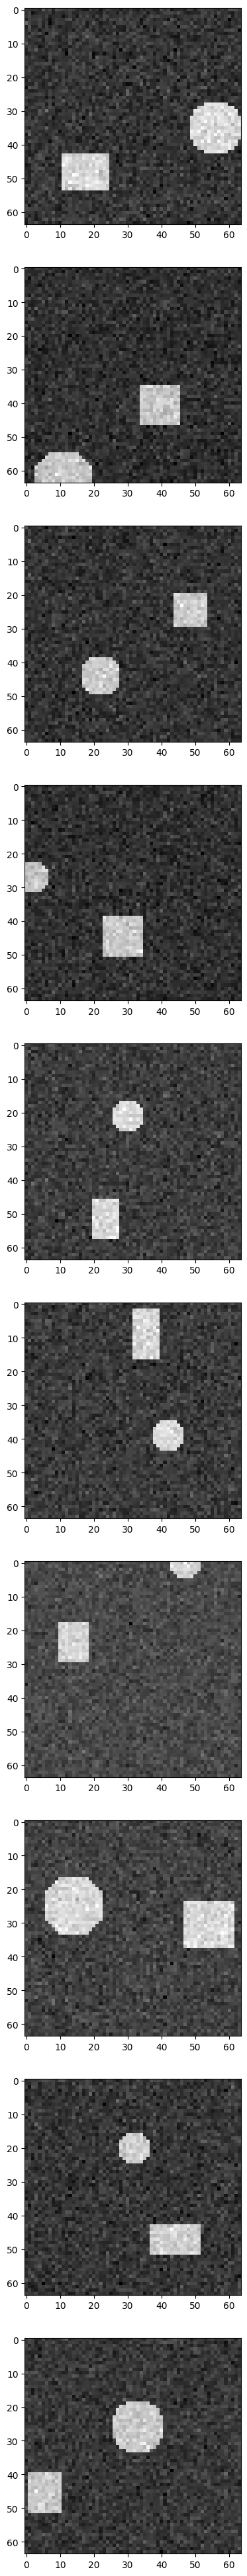

In [266]:
plt.figure(figsize=(10,50))
for i in range(1,11):
    plt.subplot(10,1,i)
    plt.imshow(next(iter(train_loader))[0].squeeze()[0], cmap="gray")
plt.show()

In [267]:
def train_function(train_loader,val_loader, model, loss_fn, optimizer, epochs=10):
    traning_loss_lst = []
    val_loss_lst = []

    best_val_loss = float('inf')
    # epochs_no_improve = 5
    best_parameters = None
    for ep in range(epochs):
        print(f"-------------------------------\nEpoch {ep+1} ...")
        train_loss = train_one_epoch(train_loader, model, loss_fn, optimizer)
        traning_loss_lst.append(train_loss)
        val_loss = test_loss(val_loader, model, loss_fn)
        val_loss_lst.append(val_loss)
        print(f"Epoch {ep+1} Train loss: {train_loss:>7f}  Val loss: {val_loss:>7f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_parameters = model.state_dict().copy()
    print("Done!")
    model.load_state_dict(best_parameters)
    return traning_loss_lst, val_loss_lst

def test_loss(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    # size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss=0
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)
        test_loss += loss.detach().item()
    test_loss /= num_batches
    return test_loss

def train_one_epoch(dataloader, model, loss_fn, optimizer):
    # size = len(dataloader.dataset)
    model.train()
    train_loss=0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        train_loss += loss.detach().item()

    train_loss /= batch
    return train_loss

def dice_score(pred, ground_truth):
  intersection = np.sum(pred * ground_truth)
  dice = (2. * intersection) / (np.sum(pred) + np.sum(ground_truth))
  return dice

def iou_score(pred, ground_truth):
  intersection = np.sum(pred * ground_truth)
  union = (np.sum(pred) + np.sum(ground_truth)) - intersection
  iou = intersection/union
  return iou


def test_function(model, test_loader):
    model.eval()
    dice_score_sum = 0.0
    iou_score_sum = 0.0
    i = 0
    with torch.no_grad():
        for images, targets in test_loader:
            images = images.to(device)
            outputs = model(images)
            outputs = torch.sigmoid(outputs)
            for pred_batch, gt_batch in zip(outputs, targets):
                for pred, gt in zip(pred_batch, gt_batch):
                    i += 1
                    pred = pred.numpy()
                    gt = gt.numpy()
                    gt = np.where(gt>0.5, 1, 0)
                    dice_score_sum += dice_score(pred, gt)
                    iou_score_sum += iou_score(pred, gt)
    
    dice_score_avg = dice_score_sum/i
    iou_score_avg = iou_score_sum/i
    print("dice score: ", dice_score_avg)
    print("iou score: ", iou_score_avg)

    return dice_score_avg, iou_score_avg

In [268]:
def plot_function(model, Dataset):
    model.eval()
    with torch.no_grad():
        input, targets = Dataset()[0]
        input, targets = input.to(device), targets.to(device)
        input_model = input.unsqueeze(0)
        outputs = model(input_model)
        outputs = torch.sigmoid(outputs)

        original_image = input.cpu()[0]
        circle_gt, square_gt = targets.cpu()
        circle_gt, square_gt = circle_gt.numpy(), square_gt.numpy()
        
        
        circle = outputs.cpu()[0][0]
        circle = circle.numpy()
        circle = np.where(circle>0.5, 1, 0)
        print("circle score")
        print("dice ", dice_score(circle, circle_gt))
        print("iou ", iou_score(circle, circle_gt))
        
        print("="*50)
        
        
        square = outputs.cpu()[0][1]
        outputs = outputs.numpy()
        square = np.where(square>0.5, 1, 0)
        print("square score")
        print("dice ", dice_score(square, square_gt))
        print("iou ", iou_score(square, square_gt))
        
        plt.figure(figsize=(20, 5))

        plt.subplot(1,3,1)
        plt.title("original")
        plt.imshow(original_image, cmap='gray')

        plt.subplot(1,3,2)
        plt.title("circle pred")
        plt.imshow(original_image, cmap='gray', alpha=1)
        plt.imshow(circle, cmap='gray', alpha=np.clip(circle, 0.5, 1.0))

        plt.subplot(1,3,3)
        plt.title("square pred")
        plt.imshow(original_image, cmap='gray', alpha=1)
        plt.imshow(square, cmap='gray', alpha=np.clip(square, 0.5, 1.0))

        plt.tight_layout()
        plt.show()

In [269]:
# Set up the model, loss function, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Autoencoder().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters())
loss_train, loss_val = train_function(train_loader,val_loader, model, criterion, optimizer, epochs=50)

-------------------------------
Epoch 1 ...
Epoch 1 Train loss: 0.353290  Val loss: 0.157591
-------------------------------
Epoch 2 ...
Epoch 2 Train loss: 0.095048  Val loss: 0.061692
-------------------------------
Epoch 3 ...
Epoch 3 Train loss: 0.059116  Val loss: 0.053221
-------------------------------
Epoch 4 ...
Epoch 4 Train loss: 0.053902  Val loss: 0.047870
-------------------------------
Epoch 5 ...
Epoch 5 Train loss: 0.051260  Val loss: 0.049451
-------------------------------
Epoch 6 ...
Epoch 6 Train loss: 0.049829  Val loss: 0.047484
-------------------------------
Epoch 7 ...
Epoch 7 Train loss: 0.048707  Val loss: 0.047810
-------------------------------
Epoch 8 ...
Epoch 8 Train loss: 0.047679  Val loss: 0.043612
-------------------------------
Epoch 9 ...
Epoch 9 Train loss: 0.046606  Val loss: 0.045803
-------------------------------
Epoch 10 ...
Epoch 10 Train loss: 0.045898  Val loss: 0.046906
-------------------------------
Epoch 11 ...
Epoch 11 Train loss: 0.

In [270]:
test_function(model, test_loader)

dice score:  0.9662363893285673
iou score:  0.9398161329116463


(0.9662363893285673, 0.9398161329116463)

circle score
dice  1.0
iou  1.0
square score
dice  1.0
iou  1.0


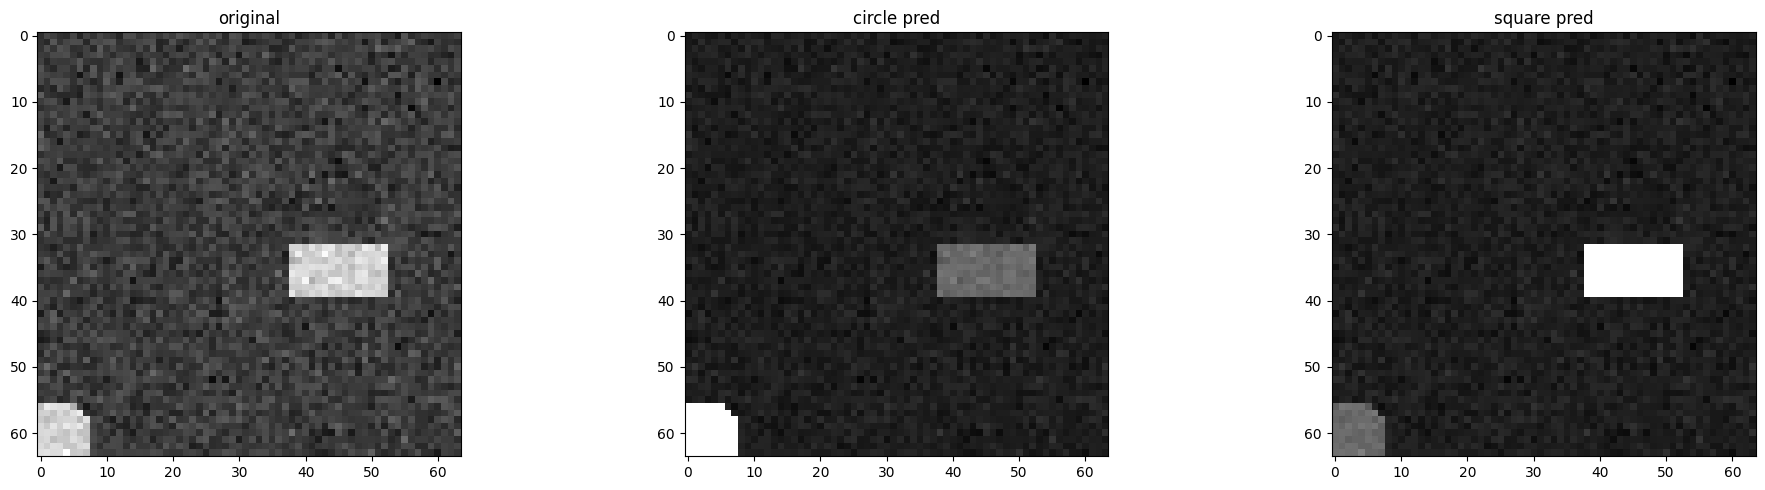

In [271]:
plot_function(model ,SimpleDataset)